In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

with open("dataset_airbnb-reviews-scraper.json", "r") as f:
    data = json.load(f)

print(type(data))
print(len(data))

<class 'list'>
4236


In [49]:
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)

In [3]:
df = pd.DataFrame(data)

df.head()

,startUrl,id,language,text,localizedText,localizedReview,localizedDate,localizedReviewerLocation,createdAt,reviewee,reviewer,reviewHighlight,highlightType,rating,response,ratingAccessibilityLabel
0,https://www.airbnb.com/rooms/1397256844122394046,1661008142605723584,en,It was amazing place with beautiful view amd e...,It was amazing place with beautiful view amd e...,None,5 days ago,1 year on Airbnb,2026-04-10T18:06:40Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '686422937', 'firstName': 'Ahmad', 'hos...",Stayed with kids,TYPE_OF_TRIP,5,None,"Rating, 5 stars"
1,https://www.airbnb.com/rooms/1397256844122394046,1659564381131618127,en,This is one of the most beautiful Air BnB’s we...,This is one of the most beautiful Air BnB’s we...,None,1 week ago,"Huntington Station, New York",2026-04-08T18:18:10Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '58902754', 'firstName': 'Mike', 'hostN...",Stayed with kids,TYPE_OF_TRIP,5,Mike we appreciate this review and I’m so happ...,"Rating, 5 stars"
2,https://www.airbnb.com/rooms/1397256844122394046,1657406013400864114,en,Beautiful Airbnb with everything you need! The...,Beautiful Airbnb with everything you need! The...,None,1 week ago,"New York, New York",2026-04-05T18:49:53Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '109732884', 'firstName': 'Katrina', 'h...",Group trip,TYPE_OF_TRIP,5,Thank you Katrina! I’m happy you gave us a che...,"Rating, 5 stars"
3,https://www.airbnb.com/rooms/1397256844122394046,1655915224623755304,en,"We had a wonderful stay! Beautiful house, beau...","We had a wonderful stay! Beautiful house, beau...",None,1 week ago,"Annapolis, Maryland",2026-04-03T17:27:57Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '396098027', 'firstName': 'Lisa', 'host...",Stayed with kids,TYPE_OF_TRIP,5,We are so happy you guys enjoyed yourselves. I...,"Rating, 5 stars"
4,https://www.airbnb.com/rooms/1397256844122394046,1653108180791647378,en,Loved the stay. Can’t wait to come back!,Loved the stay. Can’t wait to come back!,None,2 weeks ago,"Montclair, New Jersey",2026-03-30T20:30:51Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '39651124', 'firstName': 'Muneer', 'hos...",Stayed with kids,TYPE_OF_TRIP,5,You are welcome back anytime.,"Rating, 5 stars"


In [4]:
import re

def extract_room_id(url):
    if pd.isna(url):
        return None
    match = re.search(r"/rooms/(\d+)", url)
    return match.group(1) if match else None

df["room_id"] = df["startUrl"].apply(extract_room_id)

df.head()

,startUrl,id,language,text,localizedText,localizedReview,localizedDate,localizedReviewerLocation,createdAt,reviewee,reviewer,reviewHighlight,highlightType,rating,response,ratingAccessibilityLabel,room_id
0,https://www.airbnb.com/rooms/1397256844122394046,1661008142605723584,en,It was amazing place with beautiful view amd e...,It was amazing place with beautiful view amd e...,None,5 days ago,1 year on Airbnb,2026-04-10T18:06:40Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '686422937', 'firstName': 'Ahmad', 'hos...",Stayed with kids,TYPE_OF_TRIP,5,None,"Rating, 5 stars",1397256844122394046
1,https://www.airbnb.com/rooms/1397256844122394046,1659564381131618127,en,This is one of the most beautiful Air BnB’s we...,This is one of the most beautiful Air BnB’s we...,None,1 week ago,"Huntington Station, New York",2026-04-08T18:18:10Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '58902754', 'firstName': 'Mike', 'hostN...",Stayed with kids,TYPE_OF_TRIP,5,Mike we appreciate this review and I’m so happ...,"Rating, 5 stars",1397256844122394046
2,https://www.airbnb.com/rooms/1397256844122394046,1657406013400864114,en,Beautiful Airbnb with everything you need! The...,Beautiful Airbnb with everything you need! The...,None,1 week ago,"New York, New York",2026-04-05T18:49:53Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '109732884', 'firstName': 'Katrina', 'h...",Group trip,TYPE_OF_TRIP,5,Thank you Katrina! I’m happy you gave us a che...,"Rating, 5 stars",1397256844122394046
3,https://www.airbnb.com/rooms/1397256844122394046,1655915224623755304,en,"We had a wonderful stay! Beautiful house, beau...","We had a wonderful stay! Beautiful house, beau...",None,1 week ago,"Annapolis, Maryland",2026-04-03T17:27:57Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '396098027', 'firstName': 'Lisa', 'host...",Stayed with kids,TYPE_OF_TRIP,5,We are so happy you guys enjoyed yourselves. I...,"Rating, 5 stars",1397256844122394046
4,https://www.airbnb.com/rooms/1397256844122394046,1653108180791647378,en,Loved the stay. Can’t wait to come back!,Loved the stay. Can’t wait to come back!,None,2 weeks ago,"Montclair, New Jersey",2026-03-30T20:30:51Z,"{'id': '432534628', 'firstName': 'Joshua', 'ho...","{'id': '39651124', 'firstName': 'Muneer', 'hos...",Stayed with kids,TYPE_OF_TRIP,5,You are welcome back anytime.,"Rating, 5 stars",1397256844122394046


In [5]:
df_clean = df[[
    "room_id",
    "text",
    "createdAt",
    "rating",
    "reviewHighlight",
    "localizedReviewerLocation"
]].copy()

df_clean.head()

,room_id,text,createdAt,rating,reviewHighlight,localizedReviewerLocation
0,1397256844122394046,It was amazing place with beautiful view amd e...,2026-04-10T18:06:40Z,5,Stayed with kids,1 year on Airbnb
1,1397256844122394046,This is one of the most beautiful Air BnB’s we...,2026-04-08T18:18:10Z,5,Stayed with kids,"Huntington Station, New York"
2,1397256844122394046,Beautiful Airbnb with everything you need! The...,2026-04-05T18:49:53Z,5,Group trip,"New York, New York"
3,1397256844122394046,"We had a wonderful stay! Beautiful house, beau...",2026-04-03T17:27:57Z,5,Stayed with kids,"Annapolis, Maryland"
4,1397256844122394046,Loved the stay. Can’t wait to come back!,2026-03-30T20:30:51Z,5,Stayed with kids,"Montclair, New Jersey"


In [6]:
df_clean["createdAt"] = pd.to_datetime(df_clean["createdAt"])

df_clean["month"] = df_clean["createdAt"].dt.month

df_clean["is_winter"] = df_clean["month"].isin([11,12,1,2,3]).astype(int)

In [7]:
df_clean["trip_type"] = df_clean["reviewHighlight"]
df_clean["trip_type"].value_counts()

Group trip             1403
Stayed a few nights    1386
Stayed with kids        843
Stayed with a pet       401
Stayed one night         86
Stayed about a week      82
Stayed over a week        7
Name: trip_type, dtype: int64

In [8]:
df_clean["localizedReviewerLocation"].value_counts()

New York, New York        466
4 years on Airbnb         154
5 years on Airbnb         127
3 years on Airbnb         113
2 years on Airbnb         102
                         ... 
Northfield, New Jersey      1
Mount Vernon, New York      1
Bradford, Pennsylvania      1
Lakeville, New York         1
Tucson, Arizona             1
Name: localizedReviewerLocation, Length: 1390, dtype: int64

In [9]:
def clean_location(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).lower()
    
    # remove tenure / non-location
    if "year" in x or "month" in x or "trip" in x:
        return "unknown"
    
    return x

df_clean["reviewer_location_clean"] = df_clean["localizedReviewerLocation"].apply(clean_location)

In [10]:
df_clean["reviewer_location_clean"].value_counts()

unknown                     903
new york, new york          466
rochester, new york          89
new york, united states      77
boston, massachusetts        72
                           ... 
princes hill, australia       1
north bergen, new jersey      1
bloomfield, new jersey        1
hebron, new hampshire         1
harmony, pennsylvania         1
Name: reviewer_location_clean, Length: 1365, dtype: int64

In [11]:
df_clean[["reviewer_city", "reviewer_state"]] = df_clean["reviewer_location_clean"] \
    .str.split(",", n=1, expand=True)

In [12]:
df_clean["reviewer_city"] = df_clean["reviewer_city"].str.strip()
df_clean["reviewer_state"] = df_clean["reviewer_state"].str.strip()

In [13]:
df_clean["reviewer_city"] = df_clean["reviewer_city"].fillna("unknown")
df_clean["reviewer_state"] = df_clean["reviewer_state"].fillna("unknown")

In [14]:
df_clean[["reviewer_location_clean", "reviewer_city", "reviewer_state"]].head(10)

,reviewer_location_clean,reviewer_city,reviewer_state
0,unknown,unknown,unknown
1,"huntington station, new york",huntington station,new york
2,"new york, new york",new york,new york
3,"annapolis, maryland",annapolis,maryland
4,"montclair, new jersey",montclair,new jersey
5,unknown,unknown,unknown
6,"new jersey, united states",new jersey,united states
7,"new york, new york",new york,new york
8,"new york, new york",new york,new york
9,"norfolk, virginia",norfolk,virginia


In [15]:
us_states = {
    "alabama","alaska","arizona","arkansas","california","colorado","connecticut",
    "delaware","florida","georgia","hawaii","idaho","illinois","indiana","iowa",
    "kansas","kentucky","louisiana","maine","maryland","massachusetts","michigan",
    "minnesota","mississippi","missouri","montana","nebraska","nevada",
    "new hampshire","new jersey","new mexico","new york","north carolina",
    "north dakota","ohio","oklahoma","oregon","pennsylvania","rhode island",
    "south carolina","south dakota","tennessee","texas","utah","vermont",
    "virginia","washington","west virginia","wisconsin","wyoming",
    "district of columbia"
}

In [16]:
non_us_states = df_clean[
    (~df_clean["reviewer_state"].isin(us_states)) &
    (df_clean["reviewer_state"] != "Unknown")
]["reviewer_state"].value_counts()

non_us_states

unknown                       920
united states                 156
canada                         40
israel                          6
switzerland                     3
puerto rico                     2
d.c., district of columbia      2
united kingdom                  2
sri lanka                       1
australia                       1
nepal                           1
colombia                        1
el salvador                     1
andorra                         1
singapore                       1
ecuador                         1
france                          1
united arab emirates            1
austria                         1
italy                           1
nicaragua                       1
spain                           1
germany                         1
belgium                         1
Name: reviewer_state, dtype: int64

In [17]:
df_clean["reviewer_state"] = df_clean["reviewer_state"].str.lower().str.strip()

In [18]:
df_clean["reviewer_state"] = df_clean["reviewer_state"].replace({
    "d.c., district of columbia": "district of columbia"
})

In [19]:
df_clean["reviewer_state_clean"] = df_clean["reviewer_state"].apply(
    lambda x: x if x in us_states else ("unknown" if x == "unknown" else "Non-US")
)

In [20]:
df_clean["reviewer_country"] = df_clean["reviewer_state"].apply(
    lambda x: "united states" if x in us_states else x
)

In [21]:
top_countries = df_clean["reviewer_country"].value_counts().nlargest(5).index
top_countries

Index(['united states', 'unknown', 'canada', 'israel', 'switzerland'], dtype='object')

In [22]:
df_clean["reviewer_state_clean"].value_counts()

new york                1362
unknown                  920
pennsylvania             361
new jersey               322
Non-US                   225
massachusetts            190
connecticut              107
california                85
ohio                      81
florida                   69
virginia                  60
maryland                  49
texas                     44
district of columbia      33
vermont                   29
north carolina            23
colorado                  23
rhode island              20
georgia                   20
new hampshire             20
illinois                  18
michigan                  15
delaware                  15
maine                     15
washington                14
tennessee                 14
missouri                  11
minnesota                 10
south carolina             9
indiana                    9
kentucky                   8
wisconsin                  7
oregon                     5
alabama                    5
nevada        

In [23]:
df_clean_final = df_clean[[
    "room_id",
    "text",
    "createdAt",
    "rating",
    "month",
    "is_winter",
    "trip_type",
    "reviewer_city",
    "reviewer_state_clean",
    "reviewer_country"
]].copy()

df_clean_final.head()

,room_id,text,createdAt,rating,month,is_winter,trip_type,reviewer_city,reviewer_state_clean,reviewer_country
0,1397256844122394046,It was amazing place with beautiful view amd e...,2026-04-10 18:06:40+00:00,5,4,0,Stayed with kids,unknown,unknown,unknown
1,1397256844122394046,This is one of the most beautiful Air BnB’s we...,2026-04-08 18:18:10+00:00,5,4,0,Stayed with kids,huntington station,new york,united states
2,1397256844122394046,Beautiful Airbnb with everything you need! The...,2026-04-05 18:49:53+00:00,5,4,0,Group trip,new york,new york,united states
3,1397256844122394046,"We had a wonderful stay! Beautiful house, beau...",2026-04-03 17:27:57+00:00,5,4,0,Stayed with kids,annapolis,maryland,united states
4,1397256844122394046,Loved the stay. Can’t wait to come back!,2026-03-30 20:30:51+00:00,5,3,1,Stayed with kids,montclair,new jersey,united states


In [24]:
with open("airbnb-scraper.json", "r") as f:
    property_data = json.load(f)

print(type(property_data))
print(len(property_data))
df_property = pd.DataFrame(property_data)

df_property.head()

<class 'list'>
946


,id,coordinates,descriptionOriginalLanguage,metaDescription,seoTitle,sharingConfigTitle,thumbnail,url,androidLink,iosLink,...,images,breadcrumbs,highlights,houseRules,cancellationPolicies,amenities,timestamp,language,checkIn,checkOut
0,822444151106813246,"{'latitude': 42.8912, 'longitude': -76.4112}",en,"Apr 6, 2026 · Entire home · Bring the whole fa...",Skaneateles Lake House - Houses for Rent in Sk...,Home in Skaneateles · ★5.0 · 3 bedrooms · 4 be...,https://a0.muscache.com/im/pictures/miso/Hosti...,https://www.airbnb.com/rooms/82244415110681324...,airbnb://rooms/822444151106813246,airbnb://rooms/822444151106813246,...,"[{'caption': 'Family room ', 'imageUrl': 'http...","[{'linkRoute': '/', 'linkText': 'Airbnb', 'sea...","[{'title': 'Top 10% of homes', 'subtitle': 'Th...","{'additional': None, 'general': [{'title': 'Ch...","[{'policyName': 'Refundable', 'policyId': 62}]","[{'title': 'Scenic views', 'values': [{'title'...",2026-04-06T18:01:55.683Z,en,2026-04-17,2026-04-22
1,921177609969946521,"{'latitude': 42.9606, 'longitude': -76.4423}",en,"Apr 6, 2026 · Entire home · This beautiful, re...",Pet Friendly-Fenced Yard-Near Downtown - House...,Home in Skaneateles · ★5.0 · 3 bedrooms · 4 be...,https://a0.muscache.com/im/pictures/prohost-ap...,https://www.airbnb.com/rooms/92117760996994652...,airbnb://rooms/921177609969946521,airbnb://rooms/921177609969946521,...,"[{'caption': 'Equestrian style living room', '...","[{'linkRoute': '/', 'linkText': 'Airbnb', 'sea...","[{'title': 'Top 10% of homes', 'subtitle': 'Th...","{'additional': None, 'general': [{'title': 'Ch...","[{'policyName': 'Super Strict 60 Days', 'polic...","[{'title': 'Bathroom', 'values': [{'title': 'H...",2026-04-06T18:01:55.924Z,en,2026-04-20,2026-04-25
2,28640330,"{'latitude': 42.8458, 'longitude': -76.9781}",en,"Apr 6, 2026 · Entire guesthouse · Warm and cha...",Seneca Carriage House - Guesthouses for Rent i...,Guesthouse in Geneva · ★5.0 · 2 bedrooms · 3 b...,https://a0.muscache.com/im/pictures/e2f6641a-b...,https://www.airbnb.com/rooms/28640330?locale=e...,airbnb://rooms/28640330,airbnb://rooms/28640330,...,[{'caption': 'Living room with pull out couch'...,"[{'linkRoute': '/', 'linkText': 'Airbnb', 'sea...","[{'title': 'Top 1% of homes', 'subtitle': 'Thi...","{'additional': None, 'general': [{'title': 'Ch...","[{'policyName': 'Firm', 'policyId': 62}]","[{'title': 'Scenic views', 'values': [{'title'...",2026-04-06T18:02:02.865Z,en,2026-04-07,2026-04-12
3,1134026977082376916,"{'latitude': 41.83635, 'longitude': -74.13181}",en,"Apr 6, 2026 · Entire home · Callisto Farmhouse...",Callisto Farmhouse | Designer Home on 17 Acres...,Home in High Falls · ★5.0 · 3 bedrooms · 3 bed...,https://a0.muscache.com/im/pictures/miso/Hosti...,https://www.airbnb.com/rooms/11340269770823769...,airbnb://rooms/1134026977082376916,airbnb://rooms/1134026977082376916,...,"[{'caption': 'Living room image 1', 'imageUrl'...","[{'linkRoute': '/', 'linkText': 'Airbnb', 'sea...","[{'title': 'Top 10% of homes', 'subtitle': 'Th...","{'additional': None, 'general': [{'title': 'Ch...","[{'policyName': 'Flexible', 'policyId': 3}]","[{'title': 'Bathroom', 'values': [{'title': 'B...",2026-04-06T18:01:59.173Z,en,2026-04-11,2026-04-16
4,608822511328268095,"{'latitude': 42.9228, 'longitude': -76.4326}",en,"Apr 6, 2026 · Entire home · Relax, unwind & en...",Breathtaking Home with Private Pool & Lake Acc...,Home in Skaneateles · ★4.96 · 5 bedrooms · 5 b...,https://a0.muscache.com/im/pictures/edc2b074-e...,https://www.airbnb.com/rooms/60882251132826809...,airbnb://rooms/608822511328268095,airbnb://rooms/608822511328268095,...,"[{'caption': 'Living room image 1', 'imageUrl'...","[{'linkRoute': '/', 'linkText': 'Airbnb', 'sea...","[{'title': 'Top 10% of homes', 'subtitle': 'Th...","{'additional': None, 'general': [{'title': 'Ch...","[{'policyName': 'Strict', 'policyId': 44}]","[{'title': 'Scenic views', 'values': [{'title'...",2026-04-06T18:01:57.370Z,en,2026-04-06,2026-04-11


In [25]:
df_property["room_id"] = df_property["id"].astype(str)
df_clean_final["room_id"] = df_clean_final["room_id"].astype(str)

In [26]:
import re

def extract_bedrooms(text):
    if pd.isna(text):
        return None
    match = re.search(r"(\d+)\s+bedroom", text)
    return int(match.group(1)) if match else None

df_property["bedrooms"] = df_property["sharingConfigTitle"].apply(extract_bedrooms)

In [27]:
import re

def extract_price_per_night(price_dict):
    if not isinstance(price_dict, dict):
        return None
    
    try:
        desc = price_dict["breakDown"]["basePrice"]["description"]
        
        # extract number after $
        match = re.search(r"\$(\d+(?:,\d+)?(?:\.\d+)?)", desc)
        
        if match:
            return float(match.group(1).replace(",", ""))
    
    except:
        return None

df_property["price_per_night"] = df_property["price"].apply(extract_price_per_night)

In [28]:
df_property_clean = df_property[[
    "room_id",
    "location",
    "personCapacity",
    "propertyType",
    "bedrooms",
    "price_per_night"
]].copy()

In [29]:
df_property_clean

,room_id,location,personCapacity,propertyType,bedrooms,price_per_night
0,822444151106813246,Skaneateles,6,Entire home,3,486.83
1,921177609969946521,Skaneateles,8,Entire home,3,396.00
2,28640330,Geneva,4,Entire guesthouse,2,347.00
3,1134026977082376916,High Falls,6,Entire home,3,995.20
4,608822511328268095,Skaneateles,10,Entire home,5,1277.37
...,...,...,...,...,...,...
941,1395661008075010107,Lake George,8,Entire home,3,1077.20
942,661460107018389550,Fire Island,6,Entire home,3,2600.90
943,1309372041789183694,Ocean Bay Park,16,Entire home,7,3301.73
944,21236876,Colebrook,16,Entire cabin,9,3325.14


In [30]:
df_property_clean = df_property_clean.drop_duplicates(subset=["room_id"])

In [31]:
df_merged = df_clean_final.merge(
    df_property_clean,
    on="room_id",
    how="left"
)

df_merged.head()

,room_id,text,createdAt,rating,month,is_winter,trip_type,reviewer_city,reviewer_state_clean,reviewer_country,location,personCapacity,propertyType,bedrooms,price_per_night
0,1397256844122394046,It was amazing place with beautiful view amd e...,2026-04-10 18:06:40+00:00,5,4,0,Stayed with kids,unknown,unknown,unknown,West Milford,8,Entire cabin,2,473.01
1,1397256844122394046,This is one of the most beautiful Air BnB’s we...,2026-04-08 18:18:10+00:00,5,4,0,Stayed with kids,huntington station,new york,united states,West Milford,8,Entire cabin,2,473.01
2,1397256844122394046,Beautiful Airbnb with everything you need! The...,2026-04-05 18:49:53+00:00,5,4,0,Group trip,new york,new york,united states,West Milford,8,Entire cabin,2,473.01
3,1397256844122394046,"We had a wonderful stay! Beautiful house, beau...",2026-04-03 17:27:57+00:00,5,4,0,Stayed with kids,annapolis,maryland,united states,West Milford,8,Entire cabin,2,473.01
4,1397256844122394046,Loved the stay. Can’t wait to come back!,2026-03-30 20:30:51+00:00,5,3,1,Stayed with kids,montclair,new jersey,united states,West Milford,8,Entire cabin,2,473.01


In [32]:
df_scores = pd.read_csv("scored_reviews.csv")

In [33]:
print(len(df_clean_final))
print(len(df_scores))

4236
4236


In [35]:
print(len(df_merged))

4236


In [37]:
df_final = pd.concat([df_merged, df_scores], axis=1)

In [38]:
print(len(df_final))

4236


In [46]:
df_final.columns


Index(['room_id', 'text', 'createdAt', 'rating', 'month', 'is_winter',
       'trip_type', 'reviewer_city', 'reviewer_state_clean',
       'reviewer_country', 'location', 'personCapacity', 'propertyType',
       'bedrooms', 'price_per_night', 'cleanliness', 'amenities',
       'winter_amenities', 'view', 'coziness', 'activities', 'luxury',
       'negative'],
      dtype='object')

### remove all zeros

In [60]:
cols = [
    "cleanliness", "amenities", "winter_amenities",
    "view", "coziness", "activities", "luxury", "negative"
]

df_final = df_final[
    (df_final[cols].sum(axis=1) > 2)
]

In [61]:
df_final.room_id.nunique()

62

### remove extreme price

In [62]:
df_final["price_per_night"].describe()

count    3255.000000
mean      893.486209
std      1137.511463
min       305.940000
25%       391.000000
50%       529.870000
75%       796.160000
max      7376.190000
Name: price_per_night, dtype: float64

In [63]:
df_final["price_per_night"].quantile([0.1,0.8, 0.9, 0.95, 0.99])

0.10     344.53
0.80    1277.37
0.90    1838.19
0.95    2425.40
0.99    7376.19
Name: price_per_night, dtype: float64

In [64]:
q1 = df_final["price_per_night"].quantile(0.25)
q3 = df_final["price_per_night"].quantile(0.75)

df_final_clean = df_final[
    (df_final["price_per_night"] >= q1) &
    (df_final["price_per_night"] <= q3)
].copy()

In [65]:
df_final.count()

room_id                 3255
text                    3255
createdAt               3255
rating                  3255
month                   3255
is_winter               3255
trip_type               3235
reviewer_city           3255
reviewer_state_clean    3255
reviewer_country        3255
location                3255
personCapacity          3255
propertyType            3255
bedrooms                3255
price_per_night         3255
cleanliness             3255
amenities               3255
winter_amenities        3255
view                    3255
coziness                3255
activities              3255
luxury                  3255
negative                3255
dtype: int64


Bad key text.latex.unicode in file /Users/peanutbutter/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 112 ('text.latex.unicode : False # use "ucs" and "inputenc" LaTeX packages for handling')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.1/matplotlibrc.template
or from the matplotlib source distribution

Bad key text.latex.preview in file /Users/peanutbutter/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 125 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.1/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /Users/peanutbutter/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 157 ('mathtext.fallback_to_cm : True  # When Tru

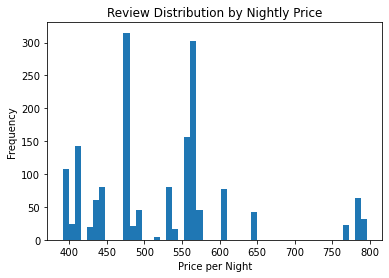

In [66]:
# Plot distribution of price_per_night from df_final

import matplotlib.pyplot as plt

# Ensure the column exists
if "price_per_night" in df_final_clean.columns:
    plt.figure()
    plt.hist(df_final_clean["price_per_night"].dropna(), bins=50)
    plt.xlabel("Price per Night")
    plt.ylabel("Frequency")
    plt.title("Review Distribution by Nightly Price")
    plt.show()
else:
    print("Column 'price_per_night' not found in df_final.")

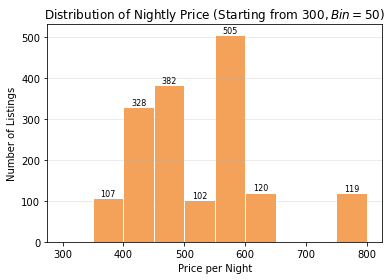

In [67]:
if "price_per_night" in df_final_clean.columns:
    
    data = df_final_clean["price_per_night"].dropna()
    
    # Define bin settings
    bin_width = 50
    start = 300
    end = data.max() + bin_width
    
    bins = np.arange(start, end, bin_width)
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(
        data,
        bins=bins,
        color="#F4A259",
        edgecolor="white"
    )
    
    # Add count labels
    for count, left, right in zip(counts, bin_edges[:-1], bin_edges[1:]):
        if count > 0:
            plt.text(
                (left + right) / 2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=8
            )
    
    plt.xlabel("Price per Night")
    plt.ylabel("Number of Listings")
    plt.title("Distribution of Nightly Price (Starting from $300, Bin = $50)")
    
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

else:
    print("Column 'price_per_night' not found in df_final_clean.")

### add segments

In [68]:
df_final_clean["segment"] = "other"

# Skaneateles
df_final_clean.loc[
    df_final_clean["location"].str.contains("Skaneateles", case=False, na=False),
    "segment"
] = "skaneateles"

# Finger Lakes
#finger_lakes = ["hector", "dundee", "penn yan", "hammondsport", "geneva"]

#df_final.loc[
#    df_final["location"].str.lower().apply(
#        lambda x: any(loc in x for loc in finger_lakes) if pd.notna(x) else False
#    ),
#    "segment"
#] = "finger_lakes"

In [69]:
winter_count = len(df_final_clean[df_final_clean["is_winter"]==1])
summer_count = len(df_final_clean[df_final_clean["is_winter"]==0])

print("Winter:", winter_count)
print("Summer:", summer_count)

Winter: 527
Summer: 1136


In [71]:
df_final_clean.groupby(["segment", "is_winter"]).size().unstack()

is_winter,0,1
segment,,
other,683,385
skaneateles,453,142


### add five-star target

In [72]:
df_final_clean["is_5star"] = (df_final_clean["rating"] == 5).astype(int)

In [73]:
df_final_clean.groupby("is_5star")[[
    "coziness", "cleanliness", "view",
    "winter_amenities", "activities"
]].mean()

,coziness,cleanliness,view,winter_amenities,activities
is_5star,,,,,
0,1.200000,1.280000,2.440000,0.240000,0.880000
1,2.079975,1.596404,2.534408,0.765654,1.458153


In [137]:
df_final_clean["createdAt"] = pd.to_datetime(df_final_clean["createdAt"])

In [138]:
start = df_final_clean["createdAt"].min()
end = df_final_clean["createdAt"].max()

print("Time range:", start, "to", end)

Time range: 2016-08-11 13:45:13+00:00 to 2026-04-12 20:55:41+00:00


In [139]:
df_final_clean["createdAt"] = pd.to_datetime(df_final_clean["createdAt"])
df_final_clean["year"] = df_final_clean["createdAt"].dt.year

In [140]:
year_counts = df_final_clean["year"].value_counts().sort_index()
print(year_counts)

2016     11
2017     35
2018     40
2019     46
2020     37
2021     81
2022    121
2023    193
2024    347
2025    610
2026    142
Name: year, dtype: int64


In [141]:
current_year = df_final_clean["createdAt"].dt.year.max()

past_5_years = df_final_clean[df_final_clean["createdAt"].dt.year >= current_year - 4]

In [142]:
total = len(df_final_clean)
past_5 = len(past_5_years)

proportion = past_5 / total

print(f"Past 5 years: {past_5} / {total} = {proportion:.2%}")

Past 5 years: 1413 / 1663 = 84.97%


### For each segment + season, what do 5-star vs non-5-star listings look like?

In [74]:
features = [
    "coziness", "cleanliness", "view",
    "amenities", "winter_amenities",
    "activities", "luxury", "negative"
]

pivot = df_final_clean.groupby(
    ["segment", "is_winter", "is_5star"]
)[features].mean().unstack()

diff = pivot.xs(1, level="is_5star", axis=1) - pivot.xs(0, level="is_5star", axis=1)

In [75]:
diff

coziness  cleanliness      view  amenities  \
segment     is_winter                                               
other       0          1.198164    -0.536622  0.404869   0.659620   
            1          1.586842     0.302632  1.181579   0.542105   
skaneateles 0          0.571879     0.877139  0.089533   0.308593   
            1          0.408759    -0.004380 -1.181022   0.908029   

                       winter_amenities  activities    luxury  negative  
segment     is_winter                                                    
other       0                  0.635917    0.328102  0.037690 -1.917788  
            1                  0.002632    0.428947 -0.984211 -2.326316  
skaneateles 0                  0.128175    0.435777  0.093677 -1.189245  
            1                  0.562044    0.440876  0.102190 -0.734307

In [76]:
pivot = df_final_clean.groupby(
    ["segment", "is_winter", "is_5star"]
)[["coziness", "cleanliness", "view", "activities","luxury"]].mean().unstack()

# compute difference: 5-star - non-5-star
diff = pivot.xs(1, level="is_5star", axis=1) - pivot.xs(0, level="is_5star", axis=1)

diff

coziness  cleanliness      view  activities    luxury
segment     is_winter                                                       
other       0          1.198164    -0.536622  0.404869    0.328102  0.037690
            1          1.586842     0.302632  1.181579    0.428947 -0.984211
skaneateles 0          0.571879     0.877139  0.089533    0.435777  0.093677
            1          0.408759    -0.004380 -1.181022    0.440876  0.102190

In [77]:
id="normalize_diff"
diff_norm = diff / pivot.xs(0, level="is_5star", axis=1)

In [78]:
df_plot = df_final_clean[
    df_final_clean["is_winter"] == 1
].groupby(["segment", "is_5star"])["coziness"].mean().unstack()

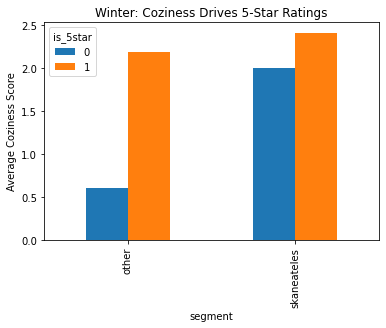

In [79]:
df_plot.plot(kind="bar")

plt.title("Winter: Coziness Drives 5-Star Ratings")
plt.ylabel("Average Coziness Score")

plt.show()

In [80]:
diff_reset = diff.reset_index()

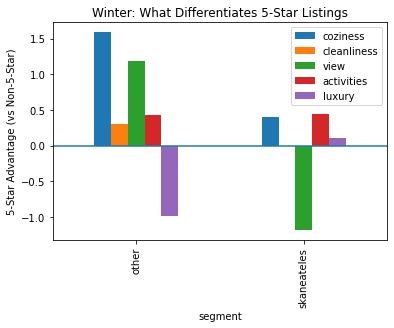

In [81]:
import matplotlib.pyplot as plt

winter = diff_reset[diff_reset["is_winter"] == 1]

winter.set_index("segment")[["coziness", "cleanliness", "view","activities","luxury"]].plot(kind="bar")

plt.title("Winter: What Differentiates 5-Star Listings")
plt.ylabel("5-Star Advantage (vs Non-5-Star)")
plt.axhline(0)

plt.show()

In [82]:
winter = diff.loc[(slice(None), 1), :].reset_index()
winter = winter.set_index("segment").loc[["skaneateles", "other"]]
winter

,is_winter,coziness,cleanliness,view,activities,luxury
segment,,,,,,
skaneateles,1,0.408759,-0.004380,-1.181022,0.440876,0.102190
other,1,1.586842,0.302632,1.181579,0.428947,-0.984211


### Compare Staneateles with other lakeside areas

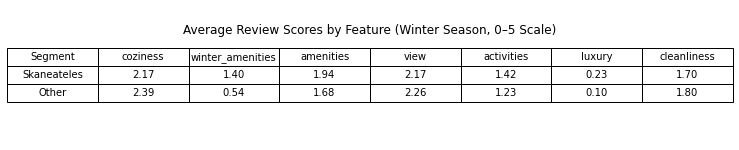

In [145]:
df_winter = df_final_clean[df_final_clean["is_winter"] == 1]

result_winter = df_winter.groupby("segment")[[
    "coziness", "winter_amenities", "amenities", "view", "activities", "luxury", "cleanliness"
]].mean()
df = result_winter.round(2).copy()
df.index = ["Skaneateles", "Other"]

df = df.reset_index()
df.rename(columns={"index": "Segment"}, inplace=True)

df_display = df.copy()
df_display.iloc[:, 1:] = df_display.iloc[:, 1:].applymap(lambda x: f"{x:.2f}")

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

# Draw table
table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    cellLoc='center',
    loc='center',
    rowLabels=None   # 🔥 THIS removes 0 / 1
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)  # adjust size

# Make columns equal width
n_cols = len(df_display.columns)
for (row, col), cell in table.get_celld().items():
    if col >= 0:
        cell.set_width(1.3 / n_cols)

# Title
plt.title(
    "Average Review Scores by Feature (Winter Season, 0–5 Scale)",
    pad=0,  y=0.8  # 🔥 reduce this (default is ~6–10)
)
plt.show()

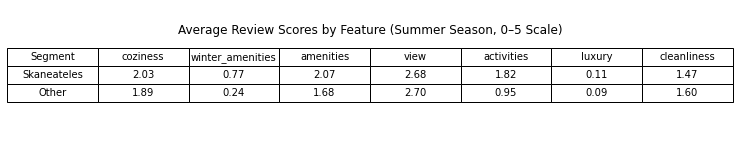

In [146]:
df_summer = df_final_clean[df_final_clean["is_winter"] == 0]

result_summer = df_summer.groupby("segment")[[
    "coziness", "winter_amenities", "amenities", "view", "activities", "luxury", "cleanliness"
]].mean()

df = result_summer.round(2).copy()
df.index = ["Skaneateles", "Other"]

df = df.reset_index()
df.rename(columns={"index": "Segment"}, inplace=True)

df_display = df.copy()
df_display.iloc[:, 1:] = df_display.iloc[:, 1:].applymap(lambda x: f"{x:.2f}")

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

# Draw table
table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    cellLoc='center',
    loc='center',
    rowLabels=None   # 🔥 THIS removes 0 / 1
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)  # adjust size

# Make columns equal width
n_cols = len(df_display.columns)
for (row, col), cell in table.get_celld().items():
    if col >= 0:
        cell.set_width(1.3 / n_cols)

# Title
plt.title(
    "Average Review Scores by Feature (Summer Season, 0–5 Scale)",
    pad=0,  y=0.8  # 🔥 reduce this (default is ~6–10)
)
plt.show()

In [147]:
df_season = df_final_clean.groupby(["segment", "is_winter"])[
    ["coziness", "winter_amenities", "amenities", "view", "activities", "luxury", "cleanliness"]
].mean().reset_index()

In [148]:
df_season["season"] = df_season["is_winter"].map({0: "Summer", 1: "Winter"})

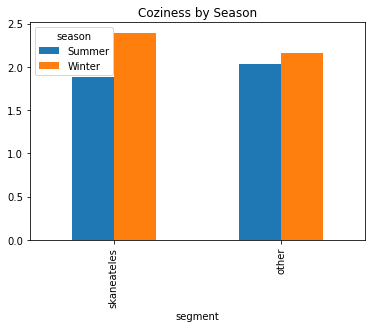

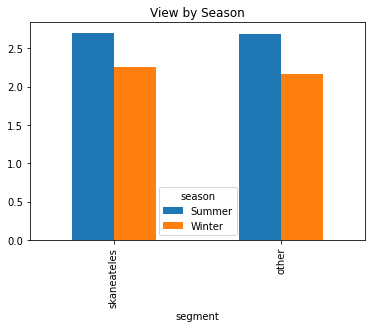

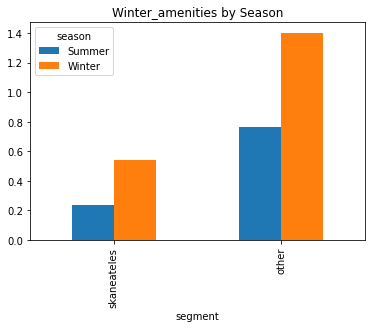

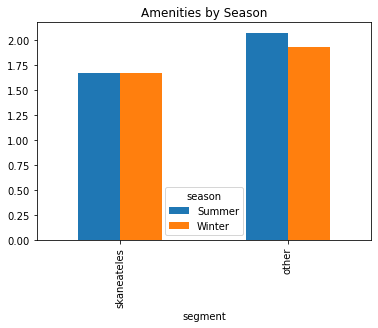

In [149]:
features = [
    "coziness",
    "view",
    "winter_amenities",
    "amenities"
]
for f in features:
    pivot = df_season.pivot(index="segment", columns="season", values=f)
    
    pivot.loc[["skaneateles", "other"]].plot(kind="bar")
    
    plt.title(f"{f.capitalize()} by Season")
    plt.show()

In [91]:
df_winter.groupby("segment")["rating"].mean().loc[["skaneateles", "other"]]

segment
skaneateles    4.964789
other          4.987013
Name: rating, dtype: float64

In [92]:
df_summer.groupby("segment")["rating"].mean().loc[["skaneateles", "other"]]

segment
skaneateles    4.933775
other          4.978038
Name: rating, dtype: float64

# Correlation

In [93]:
score_cols = [
    "cleanliness", "amenities", "winter_amenities",
    "view", "coziness", "activities", "luxury", "negative"
]

In [94]:
df_final_clean[df_final["is_winter"]==0][score_cols + ["rating"]].corr()["rating"].sort_values(ascending=False)

rating              1.000000
coziness            0.084649
winter_amenities    0.053622
amenities           0.052797
activities          0.049407
cleanliness         0.027324
luxury              0.023902
view                0.022799
negative           -0.513811
Name: rating, dtype: float64

In [360]:
def get_corr(df):
    return df[score_cols + ["rating"]].corr()["rating"].drop("rating")

results = []

for seg in df_final_clean["segment"].unique():
    for season in [0, 1]:  # 0 = summer, 1 = winter
        
        subset = df_final_clean[
            (df_final_clean["segment"] == seg) &
            (df_final_clean["is_winter"] == season)
        ]
        
        if len(subset) < 30:
            continue
        
        corr = get_corr(subset)
        corr.name = f"{seg}_{'winter' if season==1 else 'summer'}"
        results.append(corr)

corr_table = pd.concat(results, axis=1)
corr_table

,other_summer,other_winter,skaneateles_summer,skaneateles_winter
cleanliness,0.009718,0.033735,0.055005,0.065140
amenities,0.057739,0.037489,0.044176,0.064321
winter_amenities,0.050049,-0.024526,0.017410,0.034350
view,-0.001728,-0.018715,0.086502,0.055946
coziness,0.090349,0.045835,0.125218,0.092842
activities,0.037360,-0.000744,0.065920,0.009618
luxury,-0.020628,-0.033433,0.045178,0.042807
negative,-0.557502,-0.443680,-0.596757,-0.706676


In [361]:
df_final_clean[["coziness", "cleanliness", "view", "rating"]].corr()

,coziness,cleanliness,view,rating
coziness,1.000000,0.097717,0.001754,0.092610
cleanliness,0.097717,1.000000,-0.043170,0.029991
view,0.001754,-0.043170,1.000000,0.028512
rating,0.092610,0.029991,0.028512,1.000000


### Guests talk more about coziness in winter

In [315]:
df_final_clean.groupby("is_winter")[["coziness", "rating"]].mean()

,coziness,rating
is_winter,,
0,1.850854,4.952381
1,2.054217,4.965863


In [316]:
df_final_clean.groupby("is_winter")["coziness"].mean()

is_winter
0    1.850854
1    2.054217
Name: coziness, dtype: float64

In [318]:
df_final_clean["rating"].value_counts()

5    3102
4     104
3      13
2       2
1       1
Name: rating, dtype: int64

### negatives

In [493]:
df_winter.groupby("segment")["negative"].mean()

segment
other          0.103896
skaneateles    0.091549
Name: negative, dtype: float64

In [494]:
keywords = ["cold", "heat", "snow", "drive", "expensive", "value"]

for k in keywords:
    df_winter[k] = df_winter["text"].str.contains(k, case=False, na=False)

df_winter.groupby("segment")[keywords].mean()

,cold,heat,snow,drive,expensive,value
segment,,,,,,
other,0.012987,0.023377,0.109091,0.067532,0.002597,0.0
skaneateles,0.042254,0.000000,0.056338,0.133803,0.000000,0.0


In [496]:
len(df_negative)

134

In [500]:
df_ska_winter_neg = df_final_clean[
    (df_final_clean["segment"] == "skaneateles") &
    (df_final_clean["is_winter"] == 1) &
    (df_final_clean["negative"] > 0)
]

df_ska_winter_neg[[
    "room_id",
    "rating",
    "negative",
    "text"
]]

,room_id,rating,negative,text
3302,570240285455608850,5,1,"Great house, very comfortable and super clean. We had everything we needed. Our check in code wasn’t working upon arrival and Debbie responded within 60 seconds and gave me the updated code. She was kind and responsive to all of our needs. We also appreciated an earlier check in bc we had a wedding rehearsal to get to and Debbie was so helpful. Would definitely stay here again! Thank you Debbie!"
3320,1233935797446693882,5,1,"The cottage is perfect for a night or weekend away to Skaneateles. A 2-minute drive into the village area with many shops, restaurants, etc. Could be walkable in the summer months. Very close to a Byrne Dairy & Tops, as well, for any last minute supplies for your stay. The area was fairly quiet & felt safe. <br/>It was a very clean & updated space. We did notice a slight musty/old wood smell, but nothing that would prevent us from staying again or giving it 5 stars. The beds were fairly comfortable. <br/>The hosts offered many options of things to do in the area. They also left a few local beers in the fridge for us, as well. <br/>The hosts were easy to get in contact with & responded fairly quickly. <br/>We would recommend this to anyone coming for a visit & will definitely consider staying again next time we are in town!"
3363,40348767,4,2,"Albert’s place was very clean and spacious, easily accommodating four adults with three bathrooms. The view of the lake is beautiful and location is private and peaceful. The drive to Skaneateles for groceries and restaurants is about 10 minutes.<br/>We noticed that hot water for the shower smells of sulfur. Albert responded to our concerns immediately but was unable to resolve the problem during our stay. The cold water doesn’t have a problem.<br/>I also recommend driving to the location in daylight. We arrived on a late flight and the turn off the main road is hard to see, and the road to the cottage is a steep curved gravel road. I appreciated the easy to read sign with house number that makes the house easy to find.<br/>Overall, this was a very comfortable and peaceful place to stay."
3375,40348767,5,2,"We had a fantastic stay! It was right on the water and very quiet. We had a few appliance issues, but Albert was down to fix them within five minutes of me contacting him about the issues. Some of the pans were very greasy and dirty, but we just wrapped them in tinfoil. My tip for this house is to bring your own water as the water there is really stinky of sulfur. The fireplace and the wood available to use was an amazing touch and made our stay so amazing and cozy on a cold November weekend. There is plenty to explore if you like walking through the woods! We would absolutely stay here again!"
3394,40348767,5,2,This place is a winter wonderland! So much of snow and open space around. The views are amazing. The short walk down the cliff to the lake is just breathtaking.<br/>The house had loads of firewood to keep the 9 of us toasted for 8 days and probably had enough to keep us toasted for longer than a month.<br/>The water smelled of sulfur but the owner was quick to take care of it within a couple hours. <br/>They have a huge doggo that did not come with the place though :(<br/>There's kayaks and snorkelling gear as well. <br/>Will definitely want to check out this place again in summer.
3449,724657053995318269,5,1,The place is gorgeous and so uniquely laid out. We went during the Dickins Christmas event which was very charming. Debbie was responsive to my texts and very accommodating. I had a bit of trouble looking for the check in email cause it wasnt through air bnb but a quick text to Debbie sorted that out. The check in email is from Tyler so if you rent this look for his name in your email. All and all it was an amazing experience and I'd do it again!
3473,25903068,5,1,"What an incredible home!<br/>Absolutely stunning!<br/>As beautiful as the inside of the home is, the outside is even better. What 

In [503]:
df_final_clean["location"].value_counts()

Skaneateles     595
Penn Yan        246
Jay             159
Saugerties      147
Hunter          114
Dundee           86
Hector           65
Hammondsport     64
Lake George      58
Woodstock        42
Lake Placid      36
West Milford     32
Gardiner         19
Name: location, dtype: int64

In [143]:
loc_counts = df_final_clean["location"].value_counts()

top_n = 8
top_locs = loc_counts[:top_n]
others = loc_counts[top_n:].sum()

plot_data = top_locs.copy()
plot_data["Others"] = others


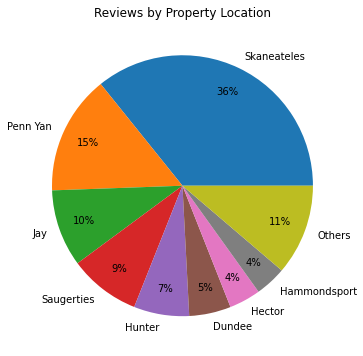

In [144]:
plt.figure(figsize=(6,6))
plot_data.plot.pie(
    autopct="%1.0f%%",
    pctdistance=0.8
)

plt.title("Reviews by Property Location")
plt.ylabel("")
plt.show()

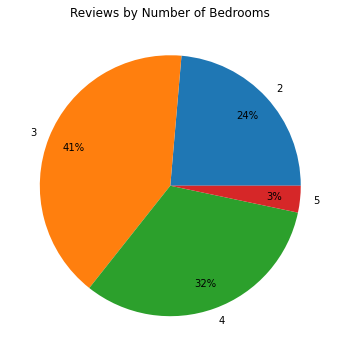

In [511]:
bed_counts = df_final_clean["bedrooms"].value_counts().sort_index()

plt.figure(figsize=(6,6))
bed_counts.plot.pie(
    autopct="%1.0f%%",
    pctdistance=0.8
)

plt.title("Reviews by Number of Bedrooms")
plt.ylabel("")
plt.show()